In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from cmdstanpy import CmdStanModel

import arviz as az

Using the 2026 dataset: https://memory.psych.upenn.edu/Data_Archive#2026

In [3]:
# Get data
data = pd.read_csv('data/Exp3_AllData.csv', header=0, sep=',')
data.head()
data = data[~np.isnan(data["Output_Rank"])]

# Convert to ints
data["Listnum"] = data["Listnum"].astype(int)
data["Spatial_Input_Order"] = data["Spatial_Input_Order"].astype(int)
data["Temporal_Input_Position"] = data["Temporal_Input_Position"].astype(int)
data["Spatial_Recall_Order"] = data["Spatial_Recall_Order"].astype(int)
data["Length"] = data["Length"].astype(int)
data["Correct"] = data["Correct"].astype(int)
data["Distance_From_Correct"] = data["Distance_From_Correct"].astype(int)
data["Serial_Pos_Encoded"] = data["Serial_Pos_Encoded"].astype(int)
data["Output_Rank"] = data["Output_Rank"].astype(int)

# Only use a fraction of the data
train_percent = 0.3
train_n = int(data.shape[0]*train_percent)
data = data.sample(n=train_n)

modif = {}
newv = []
for strin in (data["Condition"].values):
    if not(strin in modif.keys()):
        if len(modif) != 0:
            modif[strin] = modif[max(modif, key=modif.get)]+1
        else:
            modif[strin] = 1
        newv.append(modif[strin])
    else:
        newv.append(modif[strin])
    


data_dict = {
    # Sizes
    "N": data.shape[0],
    # Experiment
    "spatial_input_order": data.Spatial_Input_Order.values,
    "temporal_input_pos": data.Temporal_Input_Position.values,
    # Results
    "correct": data.Correct.values,
    #"output_rank": data.Output_Rank.values,
    "rt": data.Initial_RT_Time.values,
    "type": np.array(newv),
}

In [4]:
np.mean(data.Spatial_Input_Order.values)

np.float64(6.4881964117091595)

In [17]:
# Compile model
# Model based off of figure 7 from the paper
model = CmdStanModel(stan_file="stan/model.stan")

08:44:27 - cmdstanpy - INFO - compiling stan file /mnt/c/Users/inter/CompOrg/TinyCC/stan/model.stan to exe file /mnt/c/Users/inter/CompOrg/TinyCC/stan/model
08:44:38 - cmdstanpy - INFO - compiled model executable: /mnt/c/Users/inter/CompOrg/TinyCC/stan/model


In [25]:
# Sample model
fit = model.sample(data=data_dict, chains=4, iter_sampling=7000, iter_warmup=1000)

# Display sampling diagnostics
print(fit.diagnose())

08:51:24 - cmdstanpy - INFO - CmdStan start processing












chain 1:   0%|                                                                       | 0/8000 [00:00<?, ?it/s, (Warmup)]












chain 2:   0%|                                                                       | 0/8000 [00:00<?, ?it/s, (Warmup)]













chain 3:   0%|                                                                       | 0/8000 [00:00<?, ?it/s, (Warmup)]














chain 4:   0%|                                                                       | 0/8000 [00:00<?, ?it/s, (Warmup)]











chain 1:   0%|                                                               | 1/8000 [00:00<13:55,  9.57it/s, (Warmup)]



chain 1:   5%|███                                                          | 400/8000 [00:34<06:01, 21.00it/s, (Warmup)]





chain 3:   5%|███                                                          | 400/8000 [00:34<05:46, 21.93it/s, (Warmup)]







chain 5:   4%|██▎    


08:55:18 - cmdstanpy - INFO - CmdStan done processing.


08:55:19 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 6702 divergent transitions (95.7%)
	Chain 2 had 6567 divergent transitions (93.8%)
	Chain 3 had 6541 divergent transitions (93.4%)
	Chain 4 had 6999 divergent transitions (100.0%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
26813 of 28000 (95.76%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

The following parameters had rank-normalized split R-hat greater than 1.01:
  params[5,2]
Such high values indicate incomplete mixing and biased estimation.
You should consider regularizing your model with additional prior information or a more effective parameterization.

Processing complete.



In [26]:
fit.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-5818.750000,0.073005,3.561450,3.487740e+00,-5.825160e+03,-5.818380e+03,-5.813560e+03,2298.900,3994.650,3.947760,1.00145
"params[1,1]",-0.122735,0.002536,0.071291,7.075730e-02,-2.422700e-01,-1.228740e-01,-4.632380e-03,810.630,2244.420,1.392040,1.00186
"params[1,2]",0.576160,0.007071,0.188945,1.869080e-01,2.633150e-01,5.760290e-01,8.853740e-01,724.656,1799.790,1.244410,1.00161
"params[1,3]",-0.079901,0.001531,0.090438,9.210480e-02,-2.287850e-01,-8.011110e-02,6.780520e-02,3483.010,5572.350,5.981160,1.00090
"params[2,1]",-0.279925,0.002375,0.093325,9.494900e-02,-4.336090e-01,-2.793380e-01,-1.278640e-01,1545.430,2564.690,2.653870,1.00082
"params[2,2]",0.464046,0.007465,0.242052,2.461830e-01,7.097360e-02,4.633750e-01,8.609460e-01,1052.350,1816.390,1.807140,1.00256
"params[2,3]",0.011290,0.004289,0.119456,1.196080e-01,-1.853300e-01,1.070910e-02,2.113330e-01,764.608,1271.220,1.313010,1.00346
"params[3,1]",-1.379210,0.003315,0.101207,9.846560e-02,-1.549770e+00,-1.376230e+00,-1.218680e+00,943.018,2384.100,1.619380,1.00760
"params[3,2]",-0.117318,0.011149,0.262624,2.561160e-01,-5.432120e-01,-1.228130e-01,3.183450e-01,565.952,1948.320,0.971873,1.01402
"params[3,3]",0.229564,0.004147,0.134479,1.321480e-01,2.804120e-03,2.300820e-01,4.483710e-01,1049.160,1618.780,1.801650,1.00308


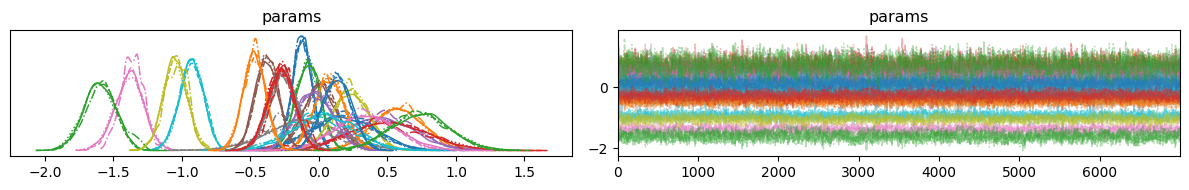

In [27]:
axarr = az.plot_trace(fit.draws_xr("params"))
plt.tight_layout()

In [28]:
def fun(a1,b1,b2,point, order):
    return a1 + b1*((point-6.5)/6.5)**2 + b2*(order-6.5)/6.5

Current TYPE is
['spatial, read silently, Varied']


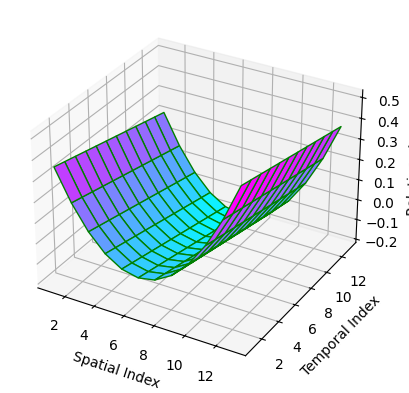

Current TYPE is
['spatial, read silently, Fixed']


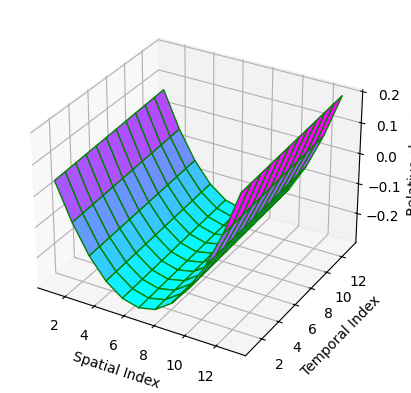

Current TYPE is
['temporal, read silently, Fixed']


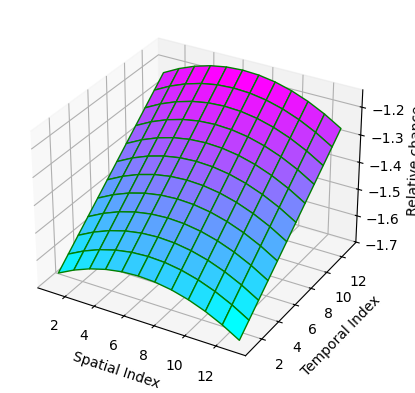

Current TYPE is
['temporal, read silently, Varied']


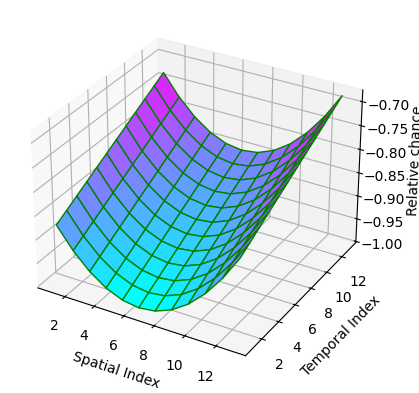

Current TYPE is
['temporal, read aloud, Fixed']


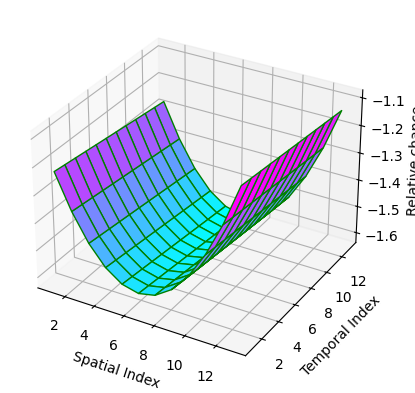

Current TYPE is
['spatial, read aloud, Fixed']


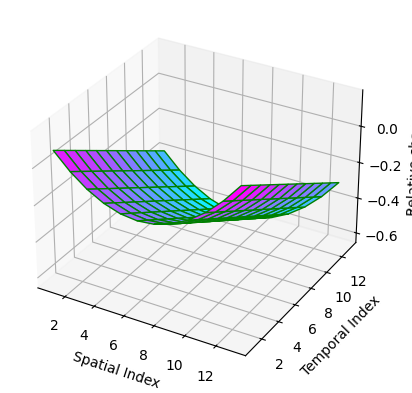

Current TYPE is
['temporal, read aloud, Varied']


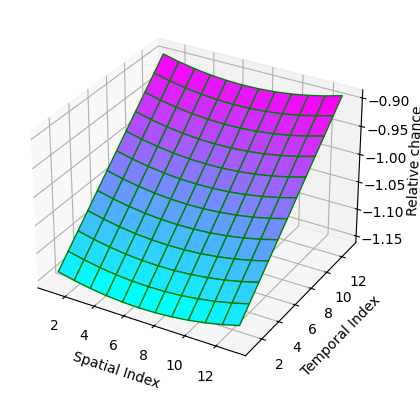

Current TYPE is
['spatial, read aloud, Varied']


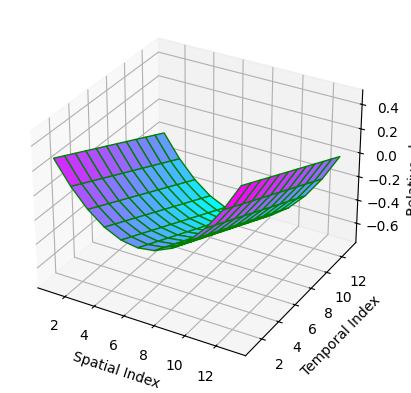

In [30]:
parameters = fit.stan_variable("params").mean(axis=0)
x = np.linspace(1,13,12)
y = np.linspace(1,13,12)
for zpem in range(0,8):
    print("Current TYPE is")
    print([key for key, val in modif.items() if val == zpem+1])
    vv = parameters[zpem]
    X, Y = np.meshgrid(x, y)
    z = fun(vv[0], vv[1], vv[2], X, Y)
    fig = plt.figure()
    ax = plt.axes(projection='3d')
    ax.plot_surface(X, Y, z, cmap='cool', edgecolor='green')
    ax.set_xlabel('Spatial Index')
    ax.set_ylabel('Temporal Index')
    ax.set_zlabel('Relative chance')
    plt.show()
    

In [ ]:
#In the graphings of the model above, I used a bernoulli_logit_lpmf which doesnt directly perscribe probability potentials onto data
#instead, giving relative contributions to the probabilty
#this allows us to analyze the patterns while not constraining the datas
#I had attempted to get an actual probability out of it by normalizing and shifting the data but STAN did not 
#allow the bounds to be within [0,1]

#From this data we can see that for temporal data, the temporal index plays a far bigger role than the spatial one. 
#It tends to increase when the temporal index increases.
#this makes sense due to the recency bias being a thing that influences how a person remembers data
#however, sometimes (like in the [temporal, read aloud, fixed]) spatial takes a far greater role
#That may be due to applying the same model to all types of analysis, which led to the temporal studies
#considering spatial to have a far greater affect than it actually does in the data.

#this shows the problems with applying a single type of model to a study which has multiple different ways of getting data
#where each change makes its own variable study